In [405]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [406]:
health_df = pd.read_excel("health_screenings_2020_1000ea.xlsx")

In [407]:
health_df.sample(10)

,year,city_code,gender,age_code,height,weight,waist,eye_left,eye_right,hear_left,...,serum,AST,ALT,GTP,smoking,drinking,oral_check,dental_caries,tartar,open_date
413,2020,28,2,13,155,65,91.0,0.9,0.9,1.0,...,0.8,25,22,15,1,NaN,0,NaN,NaN,20210929
564,2020,36,1,9,170,75,94.0,1.2,1.5,1.0,...,0.7,30,22,36,2,1.0,1,1.0,1.0,20210929
339,2020,41,1,9,170,70,79.0,0.9,1.0,1.0,...,1.1,22,22,46,2,1.0,1,0.0,1.0,20210929
730,2020,48,2,12,155,60,77.5,0.9,0.9,1.0,...,0.6,24,22,18,1,1.0,0,NaN,NaN,20210929
828,2020,27,2,13,150,55,81.0,1.0,1.0,1.0,...,0.9,24,22,16,1,NaN,0,NaN,NaN,20210929
583,2020,45,2,15,160,70,90.5,0.7,0.9,1.0,...,0.8,28,22,17,1,NaN,1,0.0,0.0,20210929
175,2020,41,1,9,170,90,93.0,1.5,1.5,1.0,...,1.0,21,22,40,2,1.0,0,NaN,NaN,20210929
608,2020,11,1,14,165,65,88.0,0.7,0.4,1.0,...,0.9,32,22,15,1,1.0,1,1.0,1.0,20210929
694,2020,36,1,9,170,80,95.0,1.0,1.5,1.0,...,0.8,19,22,45,2,1.0,0,NaN,NaN,20210929
480,2020,11,2,15,150,55,76.0,0.5,0.5,1.0,...,0.7,35,22,9,1,NaN,1,0.0,0.0,20210929


In [408]:
health_df.columns

Index(['year', 'city_code', 'gender', 'age_code', 'height', 'weight', 'waist',
       'eye_left', 'eye_right', 'hear_left', 'hear_right', 'systolic',
       'diastolic', 'blood_sugar', 'cholesterol', 'triglycerides', 'HDL',
       'LDL', 'hemoglobin', 'urine_protein', 'serum', 'AST', 'ALT', 'GTP',
       'smoking', 'drinking', 'oral_check', 'dental_caries', 'tartar',
       'open_date'],
      dtype='object')

In [409]:
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           1000 non-null   int64  
 1   city_code      1000 non-null   int64  
 2   gender         1000 non-null   int64  
 3   age_code       1000 non-null   int64  
 4   height         1000 non-null   int64  
 5   weight         1000 non-null   int64  
 6   waist          999 non-null    float64
 7   eye_left       999 non-null    float64
 8   eye_right      1000 non-null   float64
 9   hear_left      999 non-null    float64
 10  hear_right     999 non-null    float64
 11  systolic       1000 non-null   int64  
 12  diastolic      1000 non-null   int64  
 13  blood_sugar    1000 non-null   int64  
 14  cholesterol    1000 non-null   int64  
 15  triglycerides  1000 non-null   int64  
 16  HDL            1000 non-null   int64  
 17  LDL            977 non-null    float64
 18  hemoglobi

In [410]:
health_df.describe()

,year,city_code,gender,age_code,height,weight,waist,eye_left,eye_right,hear_left,...,serum,AST,ALT,GTP,smoking,drinking,oral_check,dental_caries,tartar,open_date
count,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,999.000000,999.000000,1000.000000,999.000000,...,1000.000000,1000.000000,1000.0,1000.000000,1000.00000,640.0,1000.000000,351.000000,351.000000,1000.0
mean,2020.0,33.636000,1.441000,11.308000,162.220000,64.15500,82.356757,0.968669,0.950900,1.032032,...,0.869600,24.506000,22.0,30.788000,1.38200,1.0,0.351000,0.190883,0.564103,20210929.0
std,0.0,12.798958,0.496755,2.360659,9.484807,11.57562,8.378931,0.656362,0.434843,0.176173,...,0.592441,5.534672,0.0,22.841383,0.48612,0.0,0.477522,0.393558,0.576461,0.0
min,2020.0,11.000000,1.000000,5.000000,135.000000,35.00000,56.000000,0.100000,0.100000,1.000000,...,0.300000,10.000000,22.0,6.000000,1.00000,1.0,0.000000,0.000000,0.000000,20210929.0
25%,2020.0,27.000000,1.000000,9.000000,155.000000,55.00000,77.000000,0.700000,0.700000,1.000000,...,0.700000,21.000000,22.0,18.000000,1.00000,1.0,0.000000,0.000000,0.000000,20210929.0
50%,2020.0,41.000000,1.000000,11.000000,165.000000,65.00000,82.000000,1.000000,1.000000,1.000000,...,0.800000,24.000000,22.0,24.000000,1.00000,1.0,0.000000,0.000000,1.000000,20210929.0
75%,2020.0,43.250000,2.000000,13.000000,170.000000,70.00000,88.000000,1.200000,1.200000,1.000000,...,1.000000,27.000000,22.0,35.000000,2.00000,1.0,1.000000,0.000000,1.000000,20210929.0
max,2020.0,49.000000,2.000000,17.000000,190.000000,115.00000,114.000000,9.900000,9.900000,2.000000,...,14.100000,70.000000,22.0,301.000000,2.00000,1.0,1.000000,1.000000,2.000000,20210929.0


In [411]:
health_df = health_df.dropna()

### Q3-a.) Draw a scatter plot and trend line (추세선) for cholesterol and LDL, and analyze the correlation through them.

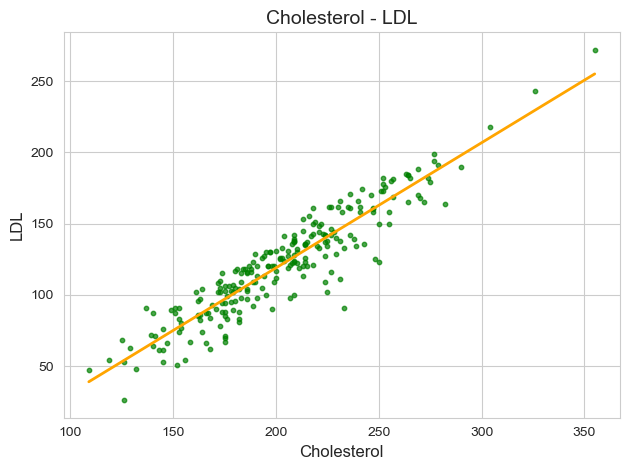

In [412]:
sns.regplot(
    x="cholesterol",
    y="LDL",
    ci=None,
    data=health_df,
    scatter_kws={"alpha": 0.7, "s": 10, "color":"green"},
    line_kws={"color":"orange", "lw":2},
)
plt.title('Cholesterol - LDL', fontsize=14)
plt.xlabel('Cholesterol', fontsize=12)
plt.ylabel('LDL', fontsize=12)
plt.tight_layout()
plt.show()


In [413]:
corr = health_df[["cholesterol", "LDL"]].corr()
corr

,cholesterol,LDL
cholesterol,1.000000,0.928231
LDL,0.928231,1.000000


### Q3-b.) Randomly select “three or more types of data” from the provided excel file, and perform visualization using “multi-plots”, thereby deriving meaningful data insights. And explain the insight.

In [414]:
health_df.columns

Index(['year', 'city_code', 'gender', 'age_code', 'height', 'weight', 'waist',
       'eye_left', 'eye_right', 'hear_left', 'hear_right', 'systolic',
       'diastolic', 'blood_sugar', 'cholesterol', 'triglycerides', 'HDL',
       'LDL', 'hemoglobin', 'urine_protein', 'serum', 'AST', 'ALT', 'GTP',
       'smoking', 'drinking', 'oral_check', 'dental_caries', 'tartar',
       'open_date'],
      dtype='object')

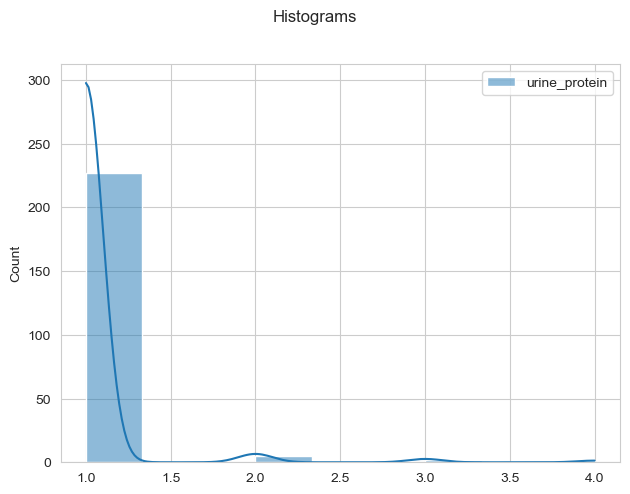

In [415]:
# histograms for some columns
# selected_columns = ["systolic", "diastolic", "cholesterol", "LDL", "HDL", "triglycerides", "BMI"]
selected_columns = ['urine_protein']
sns.histplot(health_df[selected_columns], kde=True)
plt.suptitle('Histograms', y=1.02)
plt.tight_layout()
plt.show()

In [416]:
health_df["smoking"].value_counts()

smoking
1    118
2    117
Name: count, dtype: int64

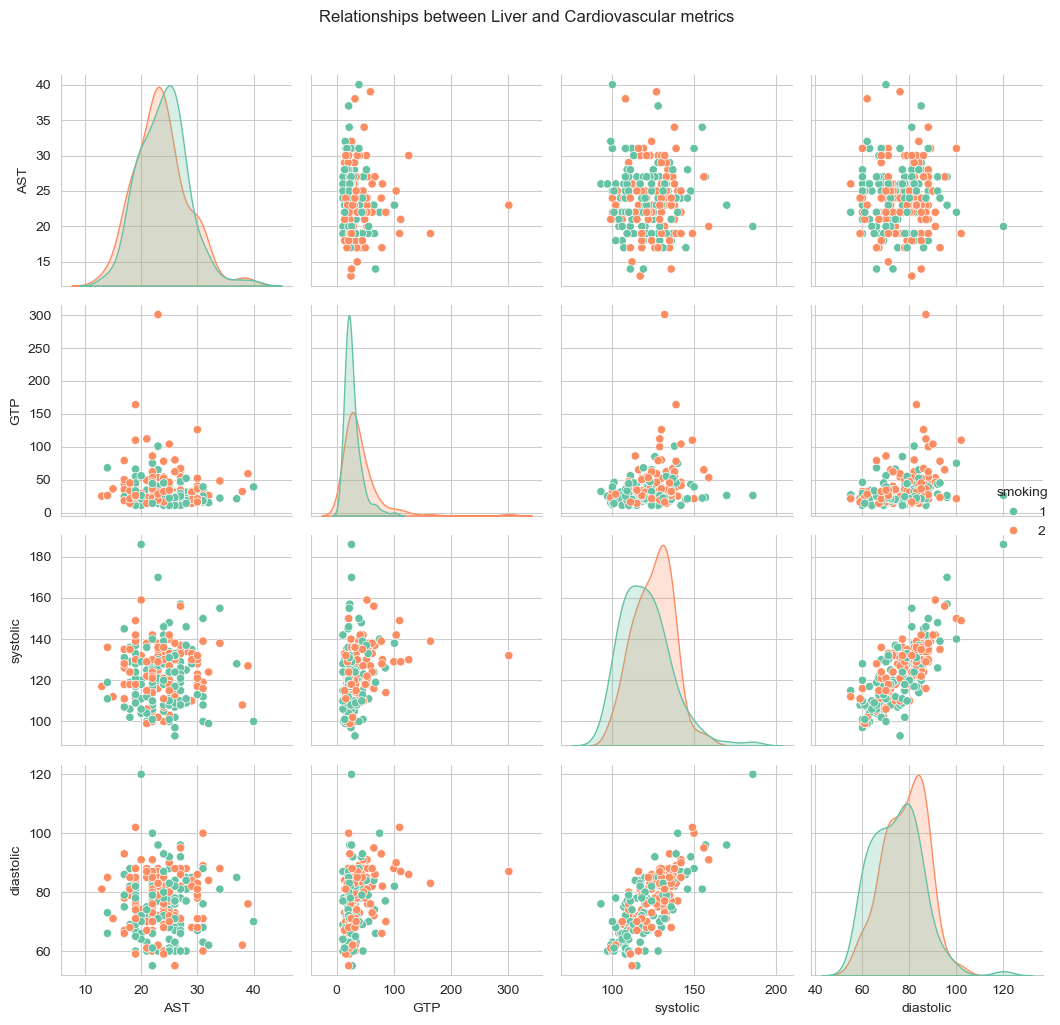

In [417]:
# selected_columns = ['GTP', 'cholesterol', 'triglycerides', 'HDL', 'LDL']
# selected_columns = ['GTP', 'systolic', 'diastolic', 'waist']
# selected_columns = ["GTP", "hemoglobin", "weight", "systolic" ]
selected_columns = ["AST", "GTP", "systolic", "diastolic"]
hue = 'smoking'
sns.pairplot(health_df[selected_columns + [hue]], hue=hue, palette='Set2')
plt.suptitle('Relationships between Liver and Cardiovascular metrics', y=1.02)
plt.tight_layout()
plt.show()

In [418]:
# Add BMI feature:
health_df["BMI"] = (health_df["weight"] / ((health_df["height"] / 100) ** 2)).round(2)

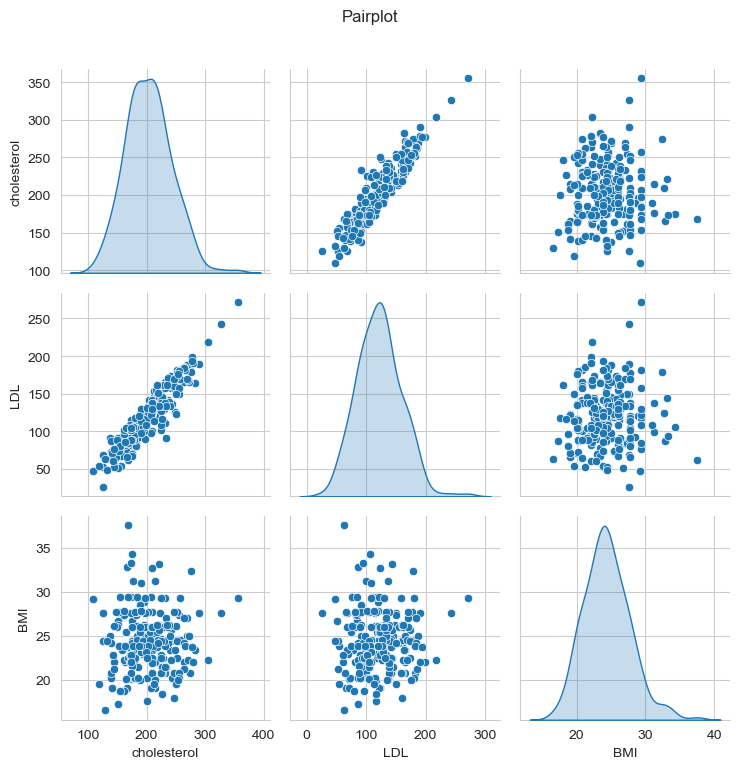

In [419]:
"""
Index(['year', 'city_code', 'gender', 'age_code', 'height', 'weight', 'waist',
       'eye_left', 'eye_right', 'hear_left', 'hear_right', 'systolic',
       'diastolic', 'blood_sugar', 'cholesterol', 'triglycerides', 'HDL',
       'LDL', 'hemoglobin', 'urine_protein', 'serum', 'AST', 'ALT', 'GTP',
       'smoking', 'drinking', 'oral_check', 'dental_caries', 'tartar',
       'open_date'],
      dtype='object')
"""

# Other combinations of columns
columns = ["cholesterol", "LDL", "BMI"]
sns.pairplot(health_df[columns], diag_kind='kde')
plt.suptitle('Pairplot', y=1.02)
plt.tight_layout()
plt.show()

### Q4. Search Matplotlib’s bubble chart, and express the data “freely” as a bubble chart using “tips dataset”.

In [420]:
tips = sns.load_dataset("tips")

In [421]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

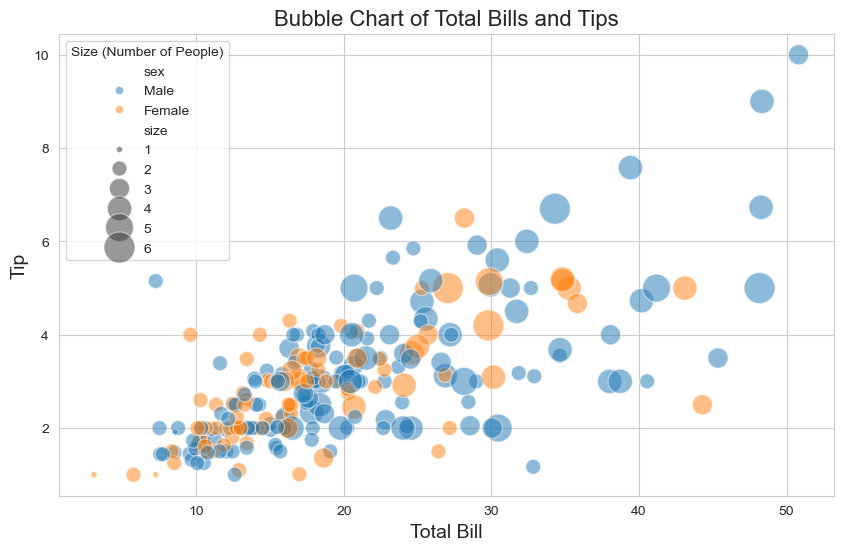

In [422]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    size="size",
    hue="sex",
    sizes=(20, 500),
    alpha=0.5,
)
plt.title("Bubble Chart of Total Bills and Tips", fontsize=16)
plt.xlabel("Total Bill", fontsize=14)
plt.ylabel("Tip", fontsize=14)
plt.legend(title="Size (Number of People)", loc="upper left")
plt.grid(True)
plt.show()

### 5. Use Treemap to visualize the population and average income of each region in Korea. At this time, freely set the regional units (시, 군, 구 등), and freely use indicators (평균 수명, 청년 인구 비율 등) instead of average income. Search and use public datasets for relevant data.

In [423]:
grdp = pd.read_csv("grdp.csv")

In [479]:
grdp["1인당 지역내총생산"] = grdp["1인당 지역내총생산"].str.replace(",", "").astype(float)
grdp["1인당 지역총소득"] = grdp["1인당 지역총소득"].str.replace(",", "").astype(float)
grdp["1인당 개인소득"] = grdp["1인당 개인소득"].str.replace(",", "").astype(float)
grdp["1인당 민간소비"] = grdp["1인당 민간소비"].str.replace(",", "").astype(float)
grdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   시도별         18 non-null     object 
 1   1인당 지역내총생산  18 non-null     float64
 2   1인당 지역총소득   18 non-null     float64
 3   1인당 개인소득    18 non-null     float64
 4   1인당 민간소비    18 non-null     float64
dtypes: float64(4), object(1)
memory usage: 848.0+ bytes


In [480]:
grdp.columns = ["시도별", "1인당 지역내총생산", "1인당 지역총소득", "1인당 개인소득", "1인당 민간소비"]

if grdp.iloc[0,0] == "시도별":
    grdp = grdp.drop(0)
    grdp = grdp.reset_index(drop=True)

In [481]:
by_major_df = pd.read_csv("by_majors.csv")

In [482]:
by_major_df.columns = by_major_df.iloc[0]
if by_major_df.iloc[0,0] == "행정구역별(시도)":
    by_major_df = by_major_df.drop(0)
    by_major_df = by_major_df.reset_index(drop=True)

In [483]:
by_major_df.head()

,행정구역별(시도),성별,직업별,전공분야별 인구(15세이상),교육,예술 및 인문학,사회과학언론 및 정보학,경영 행정 및 법,자연과학 수학 및 통계학,정보 통신 기술,공학 제조 및 건설,농림어업 및 수의학,보건 및 복지,서비스
0,전국,계,계,14792102,1474250,2184924,772643,2488246,765065,1316705,3025152,252517,1680918,831682
1,전국,계,1. 관리자,174398,30003,15466,9120,37486,8759,9550,43025,2853,13357,4779
2,전국,계,2. 전문가 및 관련 종사자,4743030,739106,723459,207849,446415,261132,404529,891021,50053,902825,116641
3,전국,계,3. 사무 종사자,3830449,251121,538048,259681,982464,217551,311118,721126,65420,295740,188180
4,전국,계,4. 서비스 종사자,1502624,147382,278523,82286,254703,67194,96000,184392,22813,161598,207733


In [484]:
by_major_df = by_major_df[(by_major_df["성별"] != "계") & (by_major_df["직업별"] == "계")]
by_major_df = by_major_df.drop(columns=["직업별"])
by_major_df = by_major_df.reset_index(drop=True)
by_major_df

,행정구역별(시도),성별,전공분야별 인구(15세이상),교육,예술 및 인문학,사회과학언론 및 정보학,경영 행정 및 법,자연과학 수학 및 통계학,정보 통신 기술,공학 제조 및 건설,농림어업 및 수의학,보건 및 복지,서비스
0,전국,남자,8675051,470086,868441,398579,1683398,449105,1035960,2646976,188479,529071,404956
1,전국,여자,6117051,1004164,1316483,374064,804848,315960,280745,378176,64038,1151847,426726
2,동부,남자,7396561,385726,752663,345221,1465190,388983,898739,2244630,130859,447230,337320
3,동부,여자,5365564,864422,1182070,332774,716766,280996,248766,332168,51100,987007,369495
4,읍부,남자,742929,47066,65406,29553,126487,35032,82708,241422,26141,48079,41035
5,읍부,여자,468126,86138,83308,25184,55184,22251,20148,29332,7030,103143,36408
6,면부,남자,535561,37294,50372,23805,91721,25090,54513,160924,31479,33762,26601
7,면부,여자,283361,53604,51105,16106,32898,12713,11831,16676,5908,61697,20823
8,서울특별시,남자,1833498,81709,240848,114233,435841,99578,227987,434158,21856,104313,72975
9,서울특별시,여자,1505863,198320,416790,117312,221153,79626,68814,84069,10032,220146,89601


In [485]:
to_drop = ["전국", "동부", "읍부", "면부"]
by_major_df = by_major_df[~by_major_df.iloc[:, 0].isin(to_drop)].reset_index(drop=True)

In [486]:
majors = ['교육', '예술 및 인문학',
          '사회과학언론 및 정보학', '경영 행정 및 법', '자연과학 수학 및 통계학', '정보 통신 기술', '공학 제조 및 건설',
          '농림어업 및 수의학', '보건 및 복지', '서비스']

def get_by_specific_major_df(major: str, df):
    if major not in df.columns:
        raise ValueError(f"'{major}' not found")

    return df[['행정구역별(시도)', "성별", major]].copy()
    # return df[major].copy()

In [496]:
def get_treemap_for_specific_major_by_income(major: str, major_df, income_df):
    major_only = get_by_specific_major_df(major, major_df)
    df_to_visualize =pd.merge(major_only, income_df[["시도별", "1인당 지역내총생산"]], left_on='행정구역별(시도)', right_on='시도별')
    df_to_visualize = df_to_visualize.drop(columns=["행정구역별(시도)"])


    fig_ = px.treemap(
        df_to_visualize,
        path=['시도별', "성별"],
        values=major,
        color='1인당 지역내총생산',
        color_continuous_scale='viridis',
        title=f'시도별 지역내 총생산(GRDP) vs {major} 전공 종사자 인구 규모',
    )

    return fig_

In [500]:
fig = get_treemap_for_specific_major_by_income("보건 및 복지", by_major_df, grdp)
fig.show()

In [498]:
fig = get_treemap_for_specific_major_by_income("정보 통신 기술", by_major_df, grdp)
fig.show()

In [499]:
fig = get_treemap_for_specific_major_by_income("공학 제조 및 건설", by_major_df, grdp)
fig.show()